<center>

# Predictor de Tiempo de Hospitalizacion 

</center>

##  Introducción

*Aquí va la introducción. Se redacta cuando el proyecto esté listo.*

##  Antecedentes

En el sector salud, la planificación de recursos es un desafío constante. Factores como la ocupación hospitalaria, la disponibilidad de camas, el personal médico y los suministros deben gestionarse cuidadosamente para garantizar una atención oportuna y de calidad. No obstante, la variabilidad en la duración de las estancias hospitalarias dificulta esta tarea, ya que cada paciente presenta características y condiciones clínicas únicas.

Tradicionalmente, las estimaciones sobre el tiempo de hospitalización se han basado en la experiencia del personal médico o en promedios históricos, métodos que pueden ser imprecisos y poco adaptables a casos individuales. En contraste, el uso de modelos predictivos basados en machine learning permite analizar grandes volúmenes de datos y encontrar patrones complejos que ayuden a estimar con mayor exactitud la duración esperada de una estancia hospitalaria.

Instituciones de salud alrededor del mundo ya están comenzando a aprovechar estas herramientas para mejorar la planificación operativa, reducir tiempos de espera y optimizar el uso de recursos hospitalarios, demostrando el valor estratégico de la predicción en este ámbito.
 

## Definición del problema

El Hospital MediCare enfrenta dificultades para calcular de manera precisa los tiempos de espera de sus pacientes. Actualmente no se consideran factores importantes como la enfermedad diagnosticada ni los resultados de las pruebas médicas, lo que provoca estimaciones poco confiables.

Además, el proceso se realiza de forma manual, lo que lo hace lento y limita la capacidad de brindar respuestas rápidas a los pacientes y al personal médico. Esto genera atrasos, insatisfacción y un uso poco eficiente de los recursos hospitalarios.

Por otro lado, las condiciones cambian constantemente (como ingresos de emergencia o la evolución de la enfermedad), pero el método actual no se ajusta con la misma rapidez. Esto reduce la posibilidad de tomar decisiones basadas en datos y de anticipar de forma adecuada los tiempos de espera.

## Justificación 

Se argumenta la necesidad de establecer un sistema automatizado que facilite la integración de diversas variables médicas y actualice los tiempos de espera en tiempo real. Así, se incrementaría la exactitud de las valoraciones, se perfeccionaría el servicio y a demás se promovería una gestión hospitalaria más eficiente.


## Objetivo general

Desarrollar un modelo de aprendizaje automático que prediga el tiempo de hospitalización de un paciente, basado en su condición médica para tomar decisiones como la capacidad del hospital.

### Objetivos específicos

- Realizar un análisis exploratorio del conjunto de datos de pacientes hospitalizados para depurar datos, identificar patrones y relaciones entre las variables.
- Entrenar modelos predictivos utilizando algoritmos de regresión para estimar el tiempo de hospitalización.
- Evaluar el rendimiento de los modelos para medir la precisión de las predicciones y seleccionar el que tenga el mejor desempeño.
- Realizar la optimización de hiperparámetros del modelo selecionado para mejorar su rendimiento.
- Desarrollar un sistema automatizado que permita utilizar las predicciones del modelo para ajustar los tiempos de hospitalización y tomar decisiones estratégicas del hospital.


## Descripción del conjunto de datos

El dataset **Healthcare Dataset** Es un conjunto de datos sintético (ficticio) creado con fines educativos y de experimentación para análisis de datos y aprendizaje automático. Se pretende emular registros hospitalarios con atributos demográficos, médicos, de facturación, admisiones, etc

## Características del Dataset
El dataset consta de las siguientes columnas:  
- `Name`: Esta columna representa el nombre del paciente asociado con el registro médico.  
- `Age`: La edad del paciente al momento de la admisión, expresada en años.
- `Gender`: Indica el género del paciente, ya sea "Male" or "Female". 
- `Blood Type`: El tipo de sangre del paciente, que puede ser uno de los tipos comunes (por ejemplo, "A+", "O-", etc.).  
- `Medical Condition`: Esta columna especifica la condición médica principal o el diagnóstico asociado con el paciente, como "Diabetes," "Hypertension," "Asthma", entre otros. 
- `Date of Admission`: La fecha en la que el paciente fue admitido en el centro de salud.  
- `Doctor`: El nombre del médico responsable del cuidado del paciente durante su admisión.  
- `Hospital`: Identifica el centro de salud u hospital donde el paciente fue admitido.  
- `Insurance Provider`: Esta columna indica el proveedor de seguro médico del paciente, que puede ser una de varias opciones, incluyendo "Aetna", "Blue Cross", "Cigna", "UnitedHealthcare" o "Medicare".
- `Billing Amount`: El monto de dinero facturado por los servicios de atención médica del paciente durante su admisión. Se expresa como un número con decimales.   
- `Room Number`: El número de la habitación donde el paciente fue alojado durante su admisión.
- `Admission Type`: Especifica el tipo de admisión, que puede ser "Emergency," "Elective," or "Urgent", reflejando las circunstancias de la admisión.  
- `Discharge Date`: La fecha en la que el paciente fue dado de alta del centro de salud, basada en la fecha de admisión y un número aleatorio de días dentro de un rango realista.  
- `Medication`: Identifica un medicamento recetado o administrado al paciente durante su admisión. Ejemplos incluyen "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," y "Lipitor".
- `Test Results`: Describe los resultados de una prueba médica realizada durante la admisión del paciente. Los valores posibles incluyen "Normal," "Abnormal," o "Inconclusive" indicando el resultado de la prueba.


## Tamaño del Dataset
- **Instancias:** 55,500 registros.  
- **Atributos:** 15 características.  

## Limitaciones
- El conjunto de datos es sintético y fue creado con fines educativos, por lo que no representa registros médicos reales.
- Al no provenir de un entorno hospitalario real, los resultados del modelo podrían no generalizarse directamente a casos prácticos en instituciones de salud.

## Acceso al Dataset
- Disponible [Healthcare Data Set](https://www.kaggle.com/datasets/prasad22/healthcare-dataset).


## Muestra del Dataset

In [ ]:
import numpy as np
import pandas as pd

In [ ]:

df_healthcare = pd.read_csv('healthcare_dataset.csv')
df_healthcare

In [ ]:
df_healthcare.head()

In [ ]:
df_healthcare.info()
#posee 55,500 filas y 15 columnas, cada fila reporta un paciente diferente. No hay valores nulos en el dataset

## Creación de la variable objetivo: duración de la hospitalización (en días)

In [ ]:
# Convertir las columnas a tipo fecha, pues estaban como objetos
df_healthcare['Date of Admission'] = pd.to_datetime(df_healthcare['Date of Admission'])
df_healthcare['Discharge Date'] = pd.to_datetime(df_healthcare['Discharge Date'])

# Crear la variable objetivo para el modelo predictivo (duración en días)
df_healthcare['Length of Stay'] = (df_healthcare['Discharge Date'] - df_healthcare['Date of Admission']).dt.days #fecha de alta - fecha de admisión

df_healthcare.head()

## Revisión rápida del data set

In [ ]:
import sys
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_healthcare.select_dtypes(include=['number']).describe()
#la media de la duración de la estancia es de 15.5 días, con una desviación estándar de 8.6 días. El valor mínimo es 1 día y el máximo es 30 días
# mean: media, std: desviación estándar, min: valor mínimo, 25%: primer cuartil, 50%: mediana, 75%: tercer cuartil, max: valor máximo

In [ ]:
#Análisis de distribuciones de las variables numéricas
#Histogramas de las variables numéricas (para detectar sesgos, multimodalidad)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df_healthcare.hist(bins=50, figsize=(12, 8)) 

#df_healthcare[['Age','Billing Amount']].hist(bins=50, figsize=(12, 4))

plt.show()

#Importante observar distribuciones con multimodalidad (transformación logarítmica - ing de características)

In [ ]:
# Boxplot individual (diagrama de caja) de la variable objetivo (Length of Stay)
# Se puede observar la distribución y posibles valores atípicos 
import seaborn as sns

bp = sns.boxplot(data=df_healthcare.loc[:, ["Length of Stay"]])

_ = bp.set_ylabel("Length of Stay")

#El rango intercuartílico (IQR) es de 8 y 23 días. 
#La mediana está en 15 días, confirma efectivamente que la estancia promedio es de 15 días.

In [ ]:
df_healthcare['Length of Stay'].describe()
#La desviación estándar 8.65, indica que hay dispersión moderada: los tiempos varían entre estancias cortas y prolongadas

### Comparación de distribuciones usando Boxplots - consultar al profe

In [ ]:
# Crear un dataFrame solo con los atributos numéricos

df_healthcareN = df_healthcare.select_dtypes(include=["number"])

In [ ]:
df_healthcareN.head()
# muestra las primeras filas para confirmar que las columnas seleccionadas son las correctas
# no todas las variables numéricas son útiles para predecir la duración de la estancia hospitalaria

In [ ]:
df_healthcareMelted = df_healthcareN.melt(var_name="Variable", value_name="Valor")

df_healthcareMelted

#crea dos columnas: "Variable" (el nombre de la columna original) y "Valor" (sus datos).

In [ ]:
# Boxplot combinado de todas las variables numéricas
# Permite comparar la distribución de todas las variables numéricas en un solo gráfico

import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x="Variable", y="Valor", data=df_healthcareMelted)
plt.title("Distribución de Variables")
plt.xticks(rotation=45)
plt.show()

### SEMANA 05

In [39]:
# Forma de identificar nulos
null_rows_idx = df_healthcare.isnull().any(axis=1)
print(null_rows_idx[null_rows_idx == True])
df_healthcare.loc[null_rows_idx].head()

Series([], dtype: bool)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,age_cat


In [40]:
#Se implementa la división del conjunto de datos en entrenamiento y prueba, un 80% y 20% respectivamente

from sklearn.model_selection import train_test_split # biblioteca de sklearn
 
train_set, test_set = train_test_split(df_healthcare, test_size=0.2, random_state=42) #proceso pseudoaleatorio
 
print('Tamaño del train_set',train_set.shape) #tamano del conjunto de entrenamiento
print('Tamaño del test_set',test_set.shape) #tamano del conjunto de pruebas

Tamaño del train_set (44400, 17)
Tamaño del test_set (11100, 17)


In [41]:
train_set.head() #muestra las primeras filas del conjunto de entrenamiento

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,age_cat
45174,CrAiG jIMENeZ,22,Female,O+,Arthritis,2022-01-01,Laura Le,Ltd Dixon,Aetna,42298.681572,336,Elective,2022-01-22,Ibuprofen,Abnormal,21,2
10214,tErreNCE coopEr,22,Male,B-,Diabetes,2020-09-20,Deborah Blackwell,"and Gates Stanley, Brennan",Blue Cross,2437.435883,486,Emergency,2020-10-12,Paracetamol,Normal,22,2
43199,RoBeRt fisheR,81,Female,A+,Arthritis,2023-02-24,Ralph Lopez,"White, Martinez and Frazier",UnitedHealthcare,5600.450992,392,Emergency,2023-03-17,Paracetamol,Abnormal,21,5
31626,nIcolE GuzmAN,80,Female,B+,Asthma,2024-02-23,Gary Perkins,Brown-Farmer,Blue Cross,39533.300775,225,Elective,2024-03-07,Paracetamol,Normal,13,5
9273,jamES burTOn,26,Female,AB+,Obesity,2023-03-04,Kevin Brown,"Bolton Arroyo and Valdez,",UnitedHealthcare,37691.176763,279,Elective,2023-03-31,Ibuprofen,Inconclusive,27,2


In [42]:
test_set.head() #muestra las primeras filas del conjunto de pruebas, no se vuelve a "tocar"

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,age_cat
31641,mIchAEl thOrnTon mD,57,Male,O+,Diabetes,2023-09-15,Jason Hanson,Thornton-Roy,Medicare,3616.898450,339,Elective,2023-10-02,Aspirin,Inconclusive,17,4
9246,mattheW HUTcHiNsOn,51,Female,A+,Diabetes,2023-10-07,Jesse Gonzalez,Wilkerson-Lewis,Aetna,36970.075481,372,Emergency,2023-10-14,Penicillin,Abnormal,7,4
1583,RoNald paRK,20,Male,A+,Asthma,2019-09-09,Sarah Hernandez,Brown-Hughes,Blue Cross,44393.001348,148,Elective,2019-10-08,Penicillin,Inconclusive,29,2
36506,Jeff BroOkS,74,Female,B+,Obesity,2020-09-14,Cathy Sanchez,"Wilson, Alexander Wolf and",Aetna,27554.923708,135,Emergency,2020-09-21,Ibuprofen,Abnormal,7,5
11259,TAnya THoMPsOn,56,Male,AB-,Obesity,2023-02-01,Nancy Lee,"Winters, Blackburn Chandler and",Aetna,27466.318567,284,Emergency,2023-02-07,Paracetamol,Inconclusive,6,4


### Estratificar columnas 

In [45]:
# Evaluar qué columnas pueden estratificarse - incialmente a ojo, luego se puede cambiar

#Se estratifica para que el train y el test tengan pacientes de todas las edades en proporciones parecidas
#Así el modelo no aprende solo de un grupo (por ejemplo jóvenes) y puede predecir mejor en general
#Se usa la edad en este caso, debido a que influye mucho en el tiempo que dura la hospitalización

df_healthcare["age_cat"] = pd.cut(df_healthcare["Age"],
                                  bins=[0., 18., 35., 50., 65., np.inf], #cortes en edades
                                  labels=[1, 2, 3, 4, 5])

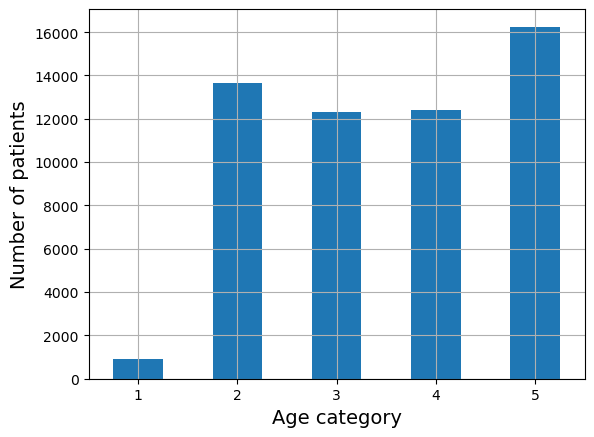

In [44]:
#Comportamiento de la variable categórica
#En X: 1: 0-18 años, 2: 19-35 años, 3: 36-50 años, 4: 51-65 años, 5: más de 65 años
#En Y: número de pacientes en cada categoría de edad

df_healthcare["age_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Age category")
plt.ylabel("Number of patients")
plt.show()

In [46]:
#Acá lo muestra distinto pero ya estratificado
# 17 columnas, 1 es la categórica de edad que se creó

from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(df_healthcare, 
                                                   test_size=0.2, 
                                                   stratify=df_healthcare["age_cat"], 
                                                   random_state=42)

print('Tamaño del train_set', strat_train_set.shape)
print('Tamaño del test_set', strat_test_set.shape)

Tamaño del train_set (44400, 17)
Tamaño del test_set (11100, 17)


## Comparación de Sets

In [47]:
# Función calcula la proporción de cada categoría de ingreso

def age_cat_proportions(data):
    return data["age_cat"].value_counts() / len(data)

In [48]:
# Asegurar que los sets aleatorios también incluyan la columna age_cat
train_set["age_cat"] = pd.cut(train_set["Age"],
                              bins=[0., 18., 35., 50., 65., np.inf], #el set de entrenamiento debe tener las mismas categorías que el original
                              labels=[1, 2, 3, 4, 5])

test_set["age_cat"] = pd.cut(test_set["Age"],
                             bins=[0., 18., 35., 50., 65., np.inf], #el set de prueba debe tener las mismas categorías que el original
                             labels=[1, 2, 3, 4, 5])


In [49]:
# Calcular las proporciones del training set aleatorio

age_cat_proportions(train_set)

age_cat
5    0.293491
2    0.244752
4    0.224865
3    0.220698
1    0.016194
Name: count, dtype: float64

In [50]:
# Calcular la proporciones del training set estratificado

age_cat_proportions(strat_train_set)

age_cat
5    0.292793
2    0.245833
4    0.223739
3    0.221644
1    0.015991
Name: count, dtype: float64

In [51]:
# Calcular las proporciones del training set aleatorio y hacer la comparación - hasta aquí revisa el profesor en semana 06

#La tabla muestra que al estratificar por edad, los grupos se reparten igual que en el dataset completo
#En cambio, si se hace al azar cambian un poco las proporciones
#Esto nos asegura que el modelo aprenda con pacientes de todas las edades de forma equitativa/justa


compare_props = pd.DataFrame({
    "Overall %": age_cat_proportions(df_healthcare), #proporciones en el dataset original
    "Stratified %": age_cat_proportions(strat_test_set), #proporciones en el set de prueba estratificado
    "Random %": age_cat_proportions(test_set), #proporciones en el set de prueba aleatorio
}).sort_index() 

compare_props.index.name = "Age Category"

compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)

compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)

(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Age Category,,,,,
1,1.60,1.60,1.52,0.23,-4.84
2,24.58,24.59,25.02,0.01,1.77
3,22.16,22.16,22.54,-0.01,1.70
4,22.37,22.37,21.92,-0.02,-2.03
5,29.28,29.28,29.00,0.00,-0.95


- Tiene un error menor de representación el estratificado.
- NO se debe tomar la variable objetivo para estratificar. 

## SEMANA 7

## Análisis exploratorio de datos (detallado) (Transformaciones de atributos)

#### Correlaciones

In [53]:
# Eliminar la columna age_cat de los sets de entrenamiento y prueba
for set_ in (strat_train_set, strat_test_set):
    set_.drop("age_cat", axis=1, inplace=True)

In [54]:
strat_train_set.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
40666,PAUL SMith,61,Female,A+,Cancer,2022-02-10,Nichole Spencer,White-Young,Blue Cross,48943.044250,471,Elective,2022-02-25,Ibuprofen,Inconclusive,15
48983,STACey HarveY Md,68,Female,O+,Cancer,2023-11-19,Jeremy Rodriguez,"Williams, Anderson Chapman and",Medicare,4197.510208,126,Elective,2023-12-07,Lipitor,Inconclusive,18
7899,DiAnE RodrIguez,43,Male,A+,Asthma,2022-08-28,Jennifer Oneal,Inc Lee,Medicare,24122.944829,263,Urgent,2022-09-21,Paracetamol,Abnormal,24
43934,rEBeCcA MCdOweLL,49,Male,B-,Obesity,2022-10-05,April Miller,Knapp-Lyons,Aetna,48934.106311,177,Urgent,2022-10-13,Paracetamol,Inconclusive,8
36171,SHErI TAylOr,20,Female,A+,Cancer,2022-04-23,Michael Brennan Jr.,Group Jones,UnitedHealthcare,34548.142723,194,Elective,2022-05-17,Penicillin,Abnormal,24


In [55]:
# Hacemos una copia para trabajar con esa, del data set en entrenamiento estratificado
dfDistTrain  = strat_train_set.copy()

- El coeficiente de correlación de Pearson es una medida estadística.
- El método corr, genera las correlaciones entre todas las variables númericas. 
- Busca una relación lineal entre las variables, de tal forma que si una variable aumenta su valor, la otra también, o lo disminuye en forma lineal.
- Valores del coeficiente de correlación:
  * 1 Correlación más fuerte.
  * 0 No hay correlación.
  * -1 Correlación muy fuerte.
- El signo lo que indica es la dirección de la relación.

In [56]:
# Matriz de correlaciones
corr_matrix = dfDistTrain.corr(numeric_only=True)
corr_matrix

,Age,Billing Amount,Room Number,Length of Stay
Age,1.000000,-0.004998,-0.002288,0.009122
Billing Amount,-0.004998,1.000000,-0.001046,-0.008118
Room Number,-0.002288,-0.001046,1.000000,-0.003756
Length of Stay,0.009122,-0.008118,-0.003756,1.000000


In [57]:
corr_matrix["Length of Stay"].sort_values(ascending=False)

Length of Stay    1.000000
Age               0.009122
Room Number      -0.003756
Billing Amount   -0.008118
Name: Length of Stay, dtype: float64

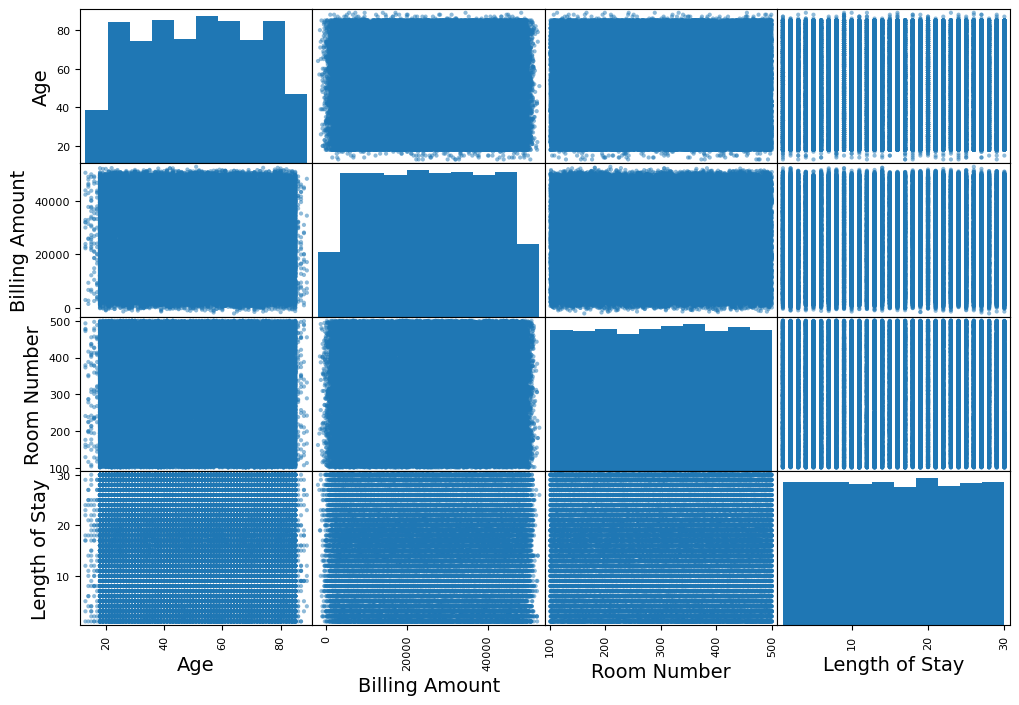

In [59]:
from pandas.plotting import scatter_matrix
 
attributes = ["Age", "Billing Amount", "Room Number","Length of Stay"]
 
scatter_matrix(dfDistTrain[attributes], figsize=(12, 8))
 
plt.show()

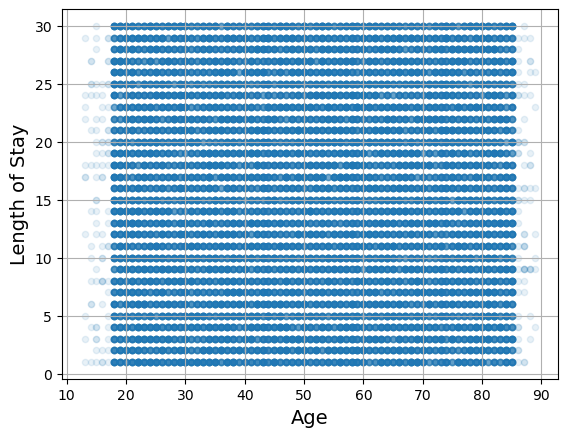

In [60]:
# Si quisieramos ver más en detalle
dfDistTrain.plot(kind='scatter', x='Age', y='Length of Stay', alpha=0.1, grid=True)
plt.show()

In [61]:
# Vamos a agrupar
gruposPorTiempoHospitalización = dfDistTrain.groupby('Length of Stay').size()
mayores25 = gruposPorTiempoHospitalización[gruposPorTiempoHospitalización > 25]
mayores25.sort_values(ascending=False)

Length of Stay
21    1551
20    1529
6     1522
14    1521
27    1513
13    1507
7     1504
9     1503
3     1501
23    1499
30    1499
19    1498
2     1494
28    1493
11    1489
29    1472
5     1471
4     1470
25    1468
17    1466
8     1466
26    1465
12    1463
1     1460
18    1448
10    1443
22    1436
15    1431
24    1414
16    1404
dtype: int64

In [62]:
# Obtener índices 
indicesBuscados = dfDistTrain[dfDistTrain['Length of Stay'] == 21].index
indicesBuscados

Index([ 9211, 38543, 42357, 14419,  5850, 52553, 31296,  6048, 51661, 22933,
       ...
       17004, 40429,  9481, 44343, 15801,   251, 14504, 53308, 51096, 29843],
      dtype='int64', length=1551)

In [63]:
# De esta forma los detectamos
dfDistTrain.loc[indicesBuscados]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
9211,kerRI ROss,24,Female,A-,Obesity,2023-05-22,Trevor Walker,Vega-Valdez,UnitedHealthcare,18197.322107,233,Emergency,2023-06-12,Penicillin,Abnormal,21
38543,ANA OSbornE,30,Female,B+,Obesity,2023-01-09,Daniel Montoya,"Fuller, Campbell Yang and",Aetna,15087.407129,144,Elective,2023-01-30,Aspirin,Abnormal,21
42357,kELseY dowNS,36,Male,A+,Arthritis,2019-06-19,James Macias,"Garcia Sellers, Phillips and",Medicare,24294.714627,348,Elective,2019-07-10,Lipitor,Inconclusive,21
14419,dr. LORI LI,65,Female,B-,Asthma,2022-06-17,Patrick Lee,Maldonado-Bryan,Medicare,49528.686320,353,Urgent,2022-07-08,Aspirin,Inconclusive,21
5850,LAuRa WeAVer,73,Female,AB+,Arthritis,2021-12-22,Matthew Gibson DVM,Phillips-Morrison,Medicare,44190.940139,410,Elective,2022-01-12,Paracetamol,Normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,mitCheLl caRrOlL,28,Female,B-,Arthritis,2022-09-10,Chad Irwin,"and Boyd Powell, Sims",Cigna,49700.324207,359,Elective,2022-10-01,Paracetamol,Abnormal,21
14504,JEsSIcA leE,73,Female,A-,Hypertension,2022-07-06,Tyler Williams,"Pace, and Greene Lambert",UnitedHealthcare,7013.005293,481,Elective,2022-07-27,Ibuprofen,Normal,21
53308,SuSan whiTakeR,37,Female,A-,Hypertension,2020-11-03,Caleb Acosta,Ltd Smith,Medicare,14183.907922,408,Urgent,2020-11-24,Ibuprofen,Inconclusive,21
51096,dENISe fRaNKLIN,66,Male,B-,Arthritis,2020-01-12,Morgan Pham,Mason-Mitchell,Medicare,17756.722581,215,Elective,2020-02-02,Paracetamol,Abnormal,21


### Experimentar con nuevos atributos

In [64]:
# Generar algunos ratios/proporciones. 
dfDistTrain["days_per_age"] = dfDistTrain["Length of Stay"] / dfDistTrain["Age"]
dfDistTrain["cost_per_day"] = dfDistTrain["Billing Amount"] / dfDistTrain["Length of Stay"]
dfDistTrain["billing_per_age"] = dfDistTrain["Billing Amount"] / dfDistTrain["Age"]

In [65]:
dfDistTrain

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,days_per_age,cost_per_day,billing_per_age
40666,PAUL SMith,61,Female,A+,Cancer,2022-02-10,Nichole Spencer,White-Young,Blue Cross,48943.044250,471,Elective,2022-02-25,Ibuprofen,Inconclusive,15,0.245902,3262.869617,802.344988
48983,STACey HarveY Md,68,Female,O+,Cancer,2023-11-19,Jeremy Rodriguez,"Williams, Anderson Chapman and",Medicare,4197.510208,126,Elective,2023-12-07,Lipitor,Inconclusive,18,0.264706,233.195012,61.728091
7899,DiAnE RodrIguez,43,Male,A+,Asthma,2022-08-28,Jennifer Oneal,Inc Lee,Medicare,24122.944829,263,Urgent,2022-09-21,Paracetamol,Abnormal,24,0.558140,1005.122701,560.998717
43934,rEBeCcA MCdOweLL,49,Male,B-,Obesity,2022-10-05,April Miller,Knapp-Lyons,Aetna,48934.106311,177,Urgent,2022-10-13,Paracetamol,Inconclusive,8,0.163265,6116.763289,998.655231
36171,SHErI TAylOr,20,Female,A+,Cancer,2022-04-23,Michael Brennan Jr.,Group Jones,UnitedHealthcare,34548.142723,194,Elective,2022-05-17,Penicillin,Abnormal,24,1.200000,1439.505947,1727.407136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54782,LOgaN rODRiguEZ,49,Male,O-,Obesity,2020-03-08,Stephanie Obrien,Ltd Brown,Medicare,44150.492445,370,Emergency,2020-03-15,Ibuprofen,Abnormal,7,0.142857,6307.213206,901.030458
14238,JAcOb LITTlE,22,Female,A+,Obesity,2021-08-10,Christian Cannon,Sons and Meyer,Aetna,18703.111808,282,Elective,2021-08-21,Penicillin,Abnormal,11,0.500000,1700.282892,850.141446
35198,HaILey HowaRD,36,Female,A-,Asthma,2019-08-06,Craig Glass,"Frey, Martin Huang and",Cigna,35938.099540,388,Emergency,2019-08-13,Ibuprofen,Abnormal,7,0.194444,5134.014220,998.280543
48978,TyleR claY,27,Female,A+,Arthritis,2021-08-24,Kathryn Garza,"Delgado Jones and Gould,",Aetna,45242.706409,162,Elective,2021-09-12,Ibuprofen,Inconclusive,19,0.703704,2381.195074,1675.655793


In [66]:
# Correlación con la columna que es la variable objetivo
corr_matrix = dfDistTrain.corr(numeric_only=True)
corr_matrix["Length of Stay"].sort_values(ascending=False)

Length of Stay     1.000000
days_per_age       0.710511
Age                0.009122
Room Number       -0.003756
Billing Amount    -0.008118
billing_per_age   -0.009888
cost_per_day      -0.538836
Name: Length of Stay, dtype: float64

### Separar variables predictivas de la objetivo

In [72]:
# Separar las variables predictivas de la variable objetivo
dfDistTrain = strat_train_set.drop("Length of Stay", axis=1)
dfDistTrain_labels = strat_train_set["Length of Stay"].copy()

#### Nulos
- Vamos a imputar los que tenga

In [73]:
# Forma alternativa de identificar nulos
null_rows_idx = dfDistTrain.isnull().any(axis=1) # Método del dataFrame
print(null_rows_idx[null_rows_idx == True]) # Quiero ver solo en los que sí hay nulos
dfDistTrain.loc[null_rows_idx].head()

Series([], dtype: bool)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


#### Forma de imputación de nulos

In [74]:
# Volvemos a hacer otra copia, esta vez la hacemos del que estamos trabajando dfDistTrain
housing_nulls = dfDistTrain.copy()
 
median = dfDistTrain["Room Number"].median() ## Se supone lo hacemos con la columna que tenga nulos
housing_nulls["Room Number"].fillna(median, inplace=True) ## Le calculamos la mediana
 
housing_nulls.loc[null_rows_idx].head()

## No debemos preocuparnos por los warnings. 

C:\Users\Daniela\AppData\Local\Temp\ipykernel_29296\1052539955.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_nulls["Room Number"].fillna(median, inplace=True) ## Le calculamos la mediana


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


## Esta es una forma más rápida de imputar

In [75]:
from sklearn.impute import SimpleImputer
 
imputer = SimpleImputer(strategy="median")

In [76]:
## Donde encuentre valores nulos los va a reemplazar con la mediana
housing_nulls = dfDistTrain.copy()
dfDistritosNumericos = housing_nulls.select_dtypes(include=[np.number])
imputer.fit(dfDistritosNumericos)

SimpleImputer(strategy='median')

In [77]:
X = imputer.transform(dfDistritosNumericos)

In [78]:
X

array([[6.10000000e+01, 4.89430443e+04, 4.71000000e+02],
       [6.80000000e+01, 4.19751021e+03, 1.26000000e+02],
       [4.30000000e+01, 2.41229448e+04, 2.63000000e+02],
       ...,
       [3.60000000e+01, 3.59380995e+04, 3.88000000e+02],
       [2.70000000e+01, 4.52427064e+04, 1.62000000e+02],
       [4.00000000e+01, 2.81229775e+04, 2.02000000e+02]])

In [79]:
# Recuperar el dataFrame
dfTrainingDistritosMod = pd.DataFrame(X, columns=dfDistritosNumericos.columns,
                                      index=dfDistritosNumericos.index)
dfTrainingDistritosMod.loc[null_rows_idx].head()

,Age,Billing Amount,Room Number


Imputadores más potentes:
- sklearn.impute
    - [KNNImputer](https://scikit-learn.org/stable/auto_examples/impute/plot_missing_values.html#sphx-glr-auto-examples-impute-plot-missing-values-py)
    - IterativeImputer

### Manejo de texto y atributos categóricos

- Muchos algoritmos no lidian bien con textos o etiquetas, por lo que hay que convertir los valores a números.
- Transformación --> Para que quede una columna con más significado para el algoritmo. 

In [80]:
healthcare_cat = dfDistTrain[["Name","Gender","Blood Type",
                              "Medical Condition","Doctor",
                              "Hospital","Insurance Provider",
                              "Admission Type","Medication","Test Results"]]
healthcare_cat.head(10)

,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
40666,PAUL SMith,Female,A+,Cancer,Nichole Spencer,White-Young,Blue Cross,Elective,Ibuprofen,Inconclusive
48983,STACey HarveY Md,Female,O+,Cancer,Jeremy Rodriguez,"Williams, Anderson Chapman and",Medicare,Elective,Lipitor,Inconclusive
7899,DiAnE RodrIguez,Male,A+,Asthma,Jennifer Oneal,Inc Lee,Medicare,Urgent,Paracetamol,Abnormal
43934,rEBeCcA MCdOweLL,Male,B-,Obesity,April Miller,Knapp-Lyons,Aetna,Urgent,Paracetamol,Inconclusive
36171,SHErI TAylOr,Female,A+,Cancer,Michael Brennan Jr.,Group Jones,UnitedHealthcare,Elective,Penicillin,Abnormal
30643,TraCY lEe,Male,A+,Arthritis,Juan Gay,Sons Pitts and,Medicare,Emergency,Aspirin,Normal
34460,AmANda COoPER,Female,A+,Arthritis,John Johnson,Hampton-Sanders,Blue Cross,Urgent,Aspirin,Inconclusive
7689,johN mONroe,Male,B-,Hypertension,Johnathan Morgan,Williams-Jones,Cigna,Emergency,Paracetamol,Abnormal
35723,Jean mATA,Female,AB-,Obesity,Thomas Powell,"Noble Caldwell, Parks and",Aetna,Emergency,Penicillin,Abnormal
14550,LIsA saNTiaGO,Male,O+,Diabetes,Corey Miller,Mccullough LLC,Cigna,Emergency,Paracetamol,Normal


In [81]:
# Ponerle a cada categoría un número
from sklearn.preprocessing import OrdinalEncoder
 
ordinal_encoder = OrdinalEncoder()
healthcare_cat_encoded = ordinal_encoder.fit_transform(healthcare_cat)
healthcare_cat_encoded[:10]

array([[1.5464e+04, 0.0000e+00, 0.0000e+00, 2.0000e+00, 2.5251e+04,
        2.8071e+04, 1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00],
       [1.7587e+04, 0.0000e+00, 6.0000e+00, 2.0000e+00, 1.4867e+04,
        2.8288e+04, 3.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00],
       [5.7280e+03, 1.0000e+00, 0.0000e+00, 1.0000e+00, 1.4631e+04,
        1.1666e+04, 3.0000e+00, 2.0000e+00, 3.0000e+00, 0.0000e+00],
       [3.6542e+04, 1.0000e+00, 5.0000e+00, 5.0000e+00, 2.7120e+03,
        1.3612e+04, 0.0000e+00, 2.0000e+00, 3.0000e+00, 1.0000e+00],
       [1.7476e+04, 0.0000e+00, 0.0000e+00, 2.0000e+00, 2.3114e+04,
        8.8750e+03, 4.0000e+00, 0.0000e+00, 4.0000e+00, 0.0000e+00],
       [1.9697e+04, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.7025e+04,
        2.4837e+04, 3.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00],
       [1.2100e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5845e+04,
        9.4820e+03, 1.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00],
       [3.0646e+04, 1.0000e+00, 5.0000e+0

In [82]:
# Ver como quedaron asociadas las diferentes categorías
ordinal_encoder.categories_

[array(['AARON bAldWIN Jr.', 'AARON hAWkIns', 'AAROn wiLsON', ...,
        'zachaRy raMirEZ', 'zacharY BauTista', 'zachary WALl'],
       dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-'], dtype=object),
 array(['Arthritis', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension',
        'Obesity'], dtype=object),
 array(['Aaron Acevedo', 'Aaron Adams', 'Aaron Aguilar', ...,
        'Zoe Nichols', 'Zoe Roberts', 'Zoe Wallace'], dtype=object),
 array(['Abbott Inc', 'Abbott Ltd', 'Abbott Moore and Williams,', ...,
        'and Zuniga Francis Peterson,', 'and Zuniga Sons',
        'and Zuniga Thompson, Blake'], dtype=object),
 array(['Aetna', 'Blue Cross', 'Cigna', 'Medicare', 'UnitedHealthcare'],
       dtype=object),
 array(['Elective', 'Emergency', 'Urgent'], dtype=object),
 array(['Aspirin', 'Ibuprofen', 'Lipitor', 'Paracetamol', 'Penicillin'],
       dtype=object),
 array(['Abnormal', 'Inconclusive', 'Normal'], dtype=object)]

In [83]:
# Otra forma de codificar, es un vector
from sklearn.preprocessing import OneHotEncoder
 
cat_encoder = OneHotEncoder()
healthcare_cat_1hot = cat_encoder.fit_transform(healthcare_cat)

In [84]:
# Usar float32 en lugar float64 para reducir el uso de memoria a la mitad
import numpy as np
small_sample_float32 = healthcare_cat_1hot[:10].toarray().astype(np.float32)

small_sample_float32

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [85]:
## Este conteo es para determinar si sirve o no utilizar OneHot
dfDistTrain[["Blood Type"]].value_counts()
## dfDistTrain[["Name","Gender","Blood Type",
                              #"Medical Condition","Doctor",
                              #"Hospital","Insurance Provider",
                              #"Admission Type","Medication","Test Results"]].value_counts()

Blood Type
B-            5594
B+            5585
AB+           5574
A-            5554
O+            5534
A+            5528
AB-           5525
O-            5506
Name: count, dtype: int64

Sugerencias ante muchas categorías:
- [category_encoders](https://github.com/scikit-learn-contrib/category_encoders)
- Embeddings (Redes neurales)

### Transformaciones logarítmicas

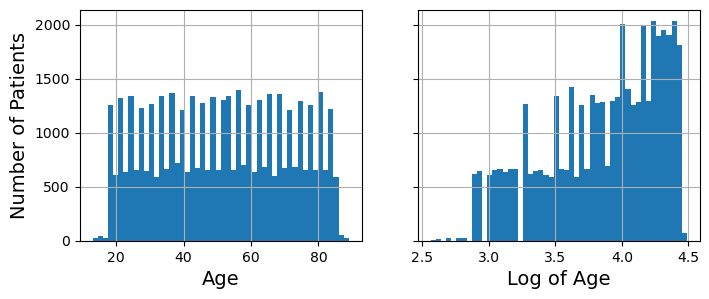

In [86]:
# Revisar porque igual el resultado no es lo que andamos buscando. 

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
 
dfDistTrain["Age"].hist(ax=axs[0], bins=50)
dfDistTrain["Age"].apply(np.log).hist(ax=axs[1], bins=50)
 
axs[0].set_xlabel("Age")
axs[1].set_xlabel("Log of Age")
axs[0].set_ylabel("Number of Patients")
 
plt.show()

### Escalar atributos 

Estrategias  (*fit* sólo training set )
- Normalización (*min-max*)
- Estandarización (menos afectada por outliers)
- Manejo de distribuciones sesgadas
    - Raíces cuadradas (o potencias entre 0 y 1)
    - Logaritmos
    - *"Bucketizing"* (como income_cat)
- Distribuciones multimodales
    - *"Bucketizing"* (one-hot encoder)
    - Funciones de base radial (Radial basis function, RBF)

#### Normalizar

In [87]:
from sklearn.preprocessing import MinMaxScaler # esta clase es la normalización
 
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
distNumMaxMin = min_max_scaler.fit_transform(dfDistritosNumericos)

In [88]:
distNumMaxMin

array([[ 0.26315789,  0.86046963,  0.85463659],
       [ 0.44736842, -0.77339096, -0.87468672],
       [-0.21052632, -0.04582377, -0.18796992],
       ...,
       [-0.39473684,  0.38560064,  0.43859649],
       [-0.63157895,  0.72535366, -0.69423559],
       [-0.28947368,  0.1002354 , -0.49373434]])

In [89]:
# Recuperar el dataFrame
dfTrainingDistritosMod = pd.DataFrame(distNumMaxMin, columns=dfDistritosNumericos.columns,
                                      index=dfDistritosNumericos.index)
dfTrainingDistritosMod

,Age,Billing Amount,Room Number
40666,0.263158,0.860470,0.854637
48983,0.447368,-0.773391,-0.874687
7899,-0.210526,-0.045824,-0.187970
43934,-0.052632,0.860143,-0.619048
36171,-0.815789,0.334847,-0.533835
...,...,...,...
54782,-0.052632,0.685472,0.348371
14238,-0.763158,-0.243726,-0.092732
35198,-0.394737,0.385601,0.438596
48978,-0.631579,0.725354,-0.694236


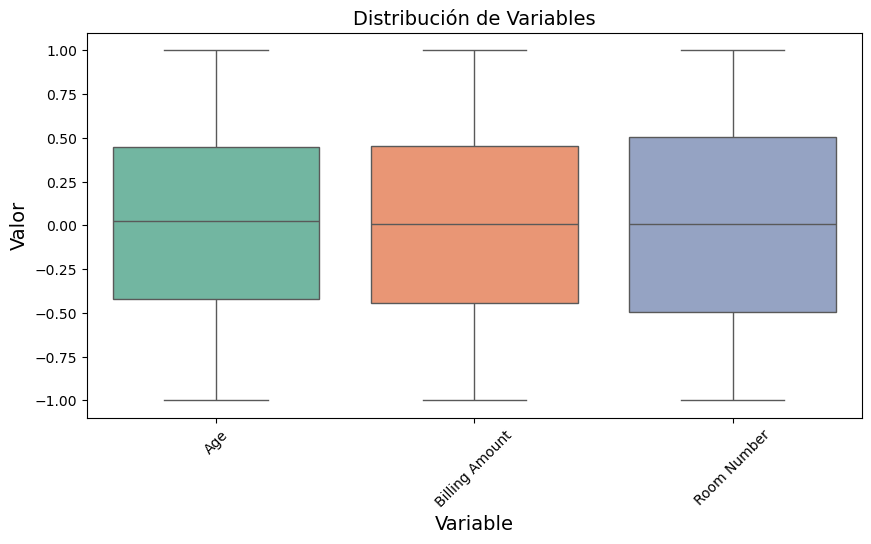

In [90]:
## Hacer boxplot para revisar
 
dfDistritosN = dfTrainingDistritosMod[["Age","Billing Amount","Room Number"]]
dfDistritosN
 
dfDistritosMelted = dfDistritosN.melt(var_name="Variable", value_name="Valor")
 
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x="Variable", y="Valor", data=dfDistritosMelted, hue= 'Variable', palette='Set2')
plt.title("Distribución de Variables")
plt.xticks(rotation=45)
plt.show()

#### Estandarizar

In [91]:
from sklearn.preprocessing import StandardScaler
 
std_scaler = StandardScaler()
distNumStd = std_scaler.fit_transform(dfDistritosNumericos)
distNumStd

array([[ 0.4839165 ,  1.64667174,  1.47171883],
       [ 0.84122777, -1.50401569, -1.51978483],
       [-0.43488392, -0.1009971 , -0.33185439],
       ...,
       [-0.79219519,  0.73094871,  0.75202375],
       [-1.2515954 ,  1.38611818, -1.20762792],
       [-0.58801732,  0.180659  , -0.86078692]])

In [92]:
# Recuperar el dataFrame
dfTrainingDistritosMod = pd.DataFrame(distNumStd, columns=dfDistritosNumericos.columns,
                                      index=dfDistritosNumericos.index)
dfTrainingDistritosMod

,Age,Billing Amount,Room Number
40666,0.483916,1.646672,1.471719
48983,0.841228,-1.504016,-1.519785
7899,-0.434884,-0.100997,-0.331854
43934,-0.128617,1.646042,-1.077563
36171,-1.608907,0.633077,-0.930155
...,...,...,...
54782,-0.128617,1.309212,0.595945
14238,-1.506818,-0.482626,-0.167105
35198,-0.792195,0.730949,0.752024
48978,-1.251595,1.386118,-1.207628


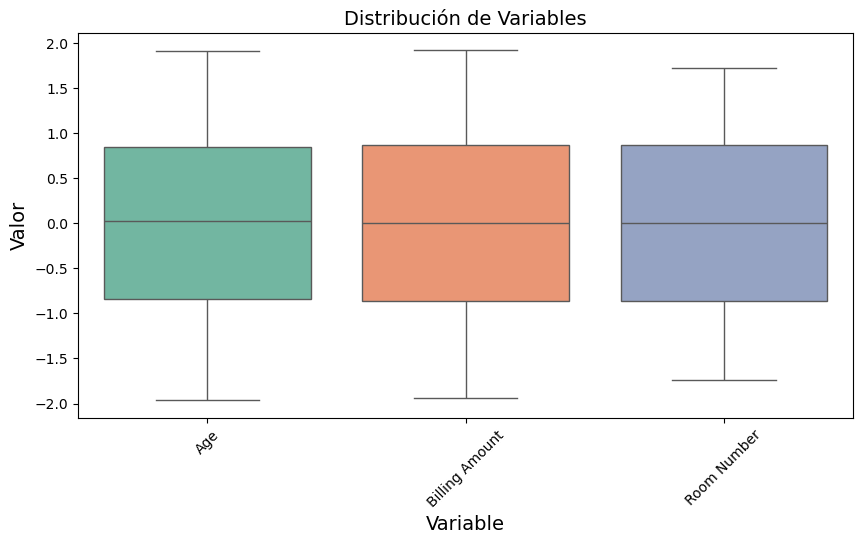

In [93]:
## Hacer boxplot para revisar
 
dfDistritosN = dfTrainingDistritosMod[["Age","Billing Amount","Room Number"]]
dfDistritosN
 
dfDistritosMelted = dfDistritosN.melt(var_name="Variable", value_name="Valor")
 
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(x="Variable", y="Valor", data=dfDistritosMelted, hue= 'Variable', palette='Set2')
plt.title("Distribución de Variables")
plt.xticks(rotation=45)
plt.show()

### Ejemplo nuevas columnas usando cluesters

In [94]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

In [95]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
 
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  
 
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


In [96]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(dfDistTrain[["Age", "Billing Amount"]],
                                           sample_weight=dfDistTrain_labels)

In [97]:
type(similarities)

numpy.ndarray

In [98]:
similarities.shape

(44400, 10)

In [99]:
similarities[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [100]:
similarities[0].max()

np.float64(0.0)

Días de Hospitalización created. Sample values: 40666    15
48983    18
7899     24
43934     8
36171    24
Name: Días de Hospitalización, dtype: int64
Columns after renaming: ['Name', 'Edad', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Cargo por Facturación', 'Número de Habitación', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Días de Hospitalización']


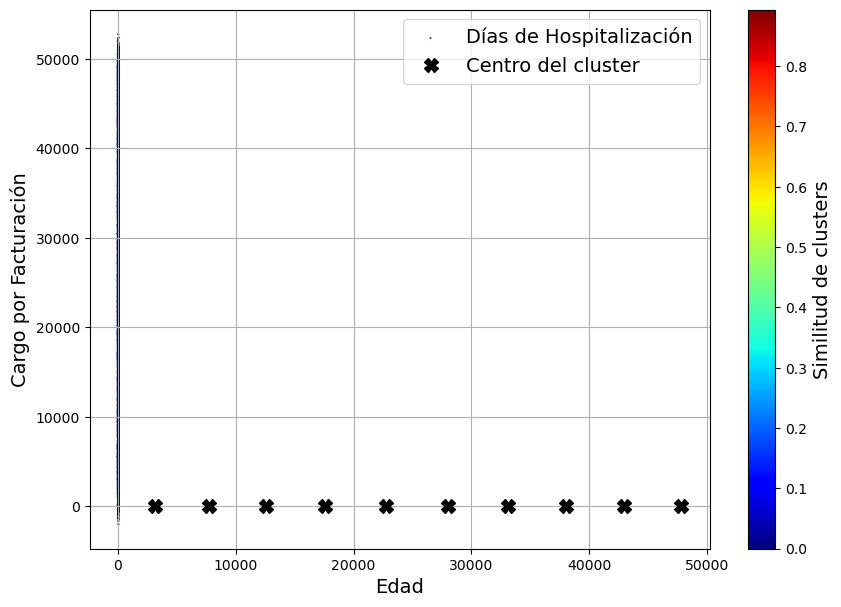

In [101]:
# Aspectos estéticos
dfDistTrain_renamed = dfDistTrain.rename(columns={"Age": "Edad",
                                                  "Billing Amount":"Cargo por Facturación",
                                                  "Room Number":"Número de Habitación"})

## Convertir a datetime
dfDistTrain_renamed['Date of Admission'] = pd.to_datetime(dfDistTrain_renamed['Date of Admission'])
dfDistTrain_renamed['Discharge Date'] = pd.to_datetime(dfDistTrain_renamed['Discharge Date'])

# Calcular length of stay
dfDistTrain_renamed['Días de Hospitalización'] = (dfDistTrain_renamed['Discharge Date'] - 
                                                 dfDistTrain_renamed['Date of Admission']).dt.days

# Validar creación
print("Días de Hospitalización created. Sample values:", dfDistTrain_renamed['Días de Hospitalización'].head())

print("Columns after renaming:", dfDistTrain_renamed.columns.tolist())

# Calculando cercanía a los principales clusters
dfDistTrain_renamed["Similitud de clusters"] = similarities.max(axis=1)
 
#np.argmax(similarities, axis=1) devuelve el identificador del cluster
 
dfDistTrain_renamed.plot(kind="scatter", x="Edad", y="Cargo por Facturación", grid=True,
                         s=dfDistTrain_renamed["Días de Hospitalización"] / 100, label="Días de Hospitalización",
                         c="Similitud de clusters",cmap="jet", colorbar=True,
                         legend=True, sharex=False, figsize=(10, 7))
 
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=10,
         label="Centro del cluster")
 
plt.legend(loc="upper right")
plt.show()       

In [102]:
kmeans01 = KMeans(n_clusters=10, n_init=10, random_state=42)
Xnuevo = dfDistTrain[["Age", "Billing Amount"]].to_numpy()
kmeans01.fit(Xnuevo, sample_weight=dfDistTrain_labels)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [103]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
 
def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)
 
def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
 
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
 
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

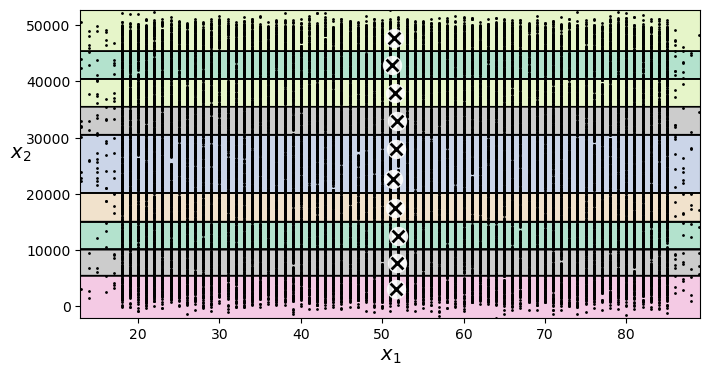

In [104]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans01, Xnuevo)
plt.show()

## Integración de práctica 4 

### Exploración de las columnas 0, 1 y 2: Name, Age y Gender, respectivamente.

#### 0. Name

In [ ]:
import sys
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_healthcare['Name'].describe()

- De acuerdo al conteo obtenido podemos determinar que el campo Name no tiene nulos, ya que el data set tiene 55500 filas/registros.
- Y casi todos los nombres son diferentes.
- El nombre má frecuente es David Munoz

#### 1. Age

In [ ]:
df_healthcare['Age'].describe()

- Un campo que tampoco tiene nulos.
- La edad media es aproximadamente 51 años, con desviación estándar cercana a 19.6.

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df_healthcare['Age'], bins=20, edgecolor='black', color='skyblue')
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

- Generamos el histograma para mostrar la distribución de la Edad, la cual es relativamente normal, con ligera concentración entre los 40 y 60 años.

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_healthcare['Age'], color='lightblue')
plt.title('Boxplot de Edad')
plt.xlabel('Edad')
plt.show()

- Adicional, el boxplot no muestra valores atípicos significativos, lo que sugiere calidad y consistencia en el registro de edades.

In [ ]:
df_healthcare["Age_Group"] = pd.cut(df_healthcare["Age"], bins=[0,12,18,40,65,80],
                         labels=["Infancia","Adolescente","Joven Adulto","Adulto","Adulto Mayor"])
df_healthcare["Age_Group"].value_counts()

- Las etiquetas por grupo de edades muestran que el segmento predominante es el de Adulto, y Jove Adulto y Adulto Mayor.

#### 2. Gender

In [ ]:
df_healthcare['Gender'].value_counts()
print("\nPorcentajes:")
df_healthcare['Gender'].value_counts(normalize=True) * 100

- El dataset está prácticamente equilibrado, no existe sesgo de género en la muestra.

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Gender', data=df_healthcare, palette='pastel', legend=False)
plt.title('Distribución por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Pacientes')
plt.show()

#### Comparación entre Age y Gender

In [ ]:
df_healthcare.groupby('Gender')['Age'].describe()

- No se observan diferencias sustanciales entre géneros respecto a la edad promedio.

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Age", hue='Gender', data=df_healthcare, palette="Set2")
plt.title("Comparación de Edad según Género")
plt.xlabel("Género")
plt.ylabel("Edad")
plt.show()

#### Generación de training set y test set
- De forma aleatoria generamos el training y test set, tomando solo en cuenta los atributos que estoy utilizando (Name, Age, Gender)


In [ ]:
from sklearn.model_selection import train_test_split

df_columns = df_healthcare[["Name", "Age", "Gender"]].copy()
df_columns.head()

In [ ]:
# División aleatoria del dataset
train_set, test_set = train_test_split(df_columns, test_size=0.2, random_state=42)

print("Tamaño del train_set:", train_set.shape)
print("Tamaño del test_set:", test_set.shape)

#### Estratificación por edad

In [ ]:
# Creamos categoría 

df_columns["age_cat"] = pd.cut(df_columns["Age"],
                                bins=[0,18,30,50,70,np.inf],
                                labels=[1,2,3,4,5])

df_columns

In [ ]:
# Gráfico de Barra de age_cat
df_columns["age_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

plt.xlabel("Age category")
plt.ylabel("Number of records")
plt.title("Distribution of age_cat")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
 
# === ESTRATIFICADO 80/20 POR age_cat ===
strat_train_set, strat_test_set = train_test_split(
    df_columns, test_size=0.2, stratify=df_columns["age_cat"], random_state=42
)
print('Tamaño del train_set',strat_train_set.shape)
print('Tamaño del test_set',strat_test_set.shape)

#### Comparaciones entre los sets

In [ ]:
train_set, test_set = train_test_split(df_columns, test_size=0.2, random_state=42)

In [ ]:
#Comparación de proporciones y errores
def age_cat_proportions(data):
    return data["age_cat"].value_counts() / len(data)

In [ ]:
# Comparación de proporciones
compare_props = pd.DataFrame({
    "Overall %": age_cat_proportions(df_columns),
    "Stratified %": age_cat_proportions(strat_test_set),
    "Random %": age_cat_proportions(test_set),
}).sort_index()

# Calcular errores relativos
compare_props["Strat. Error %"] = (
    compare_props["Stratified %"] / compare_props["Overall %"] - 1
)
compare_props["Rand. Error %"] = (
    compare_props["Random %"] / compare_props["Overall %"] - 1
)

# Mostrar resultado en porcentaje redondeado
(compare_props * 100).round(2)

- La tabla compare_props muestra que las diferencias entre los porcentajes globales y estratificados son cercanas a 0%, lo cual valida la correcta segmentación.

#### Correlación, Normalización, Estandarización ...

In [ ]:
dfDistTrain = strat_train_set.copy()   # estratificado por age_cat en tu Punto 2

# Correlación (numérica)
dfDistTrain_num = dfDistTrain.copy()
dfDistTrain_num["Gender_num"] = dfDistTrain_num["Gender"].map({"Female": 0, "Male": 1})

# Correlación entre variables numéricas disponibles
corr_matrix = dfDistTrain_num[["Age", "Gender_num"]].corr(numeric_only=True)
print("\nMatriz de correlación (Age, Gender_num):\n", corr_matrix)

# correlación con Age
print("\nCorrelación ordenada respecto a Age:")
print(corr_matrix["Age"].sort_values(ascending=False))

- La correlación entre Age y Gender_num (versión numérica de género) es prácticamente 0, indicando que no existe relación lineal entre ambos atributos.

In [ ]:
# Etiquetas/categorías de edad (bucketizing)

if "age_cat" not in dfDistTrain.columns:
    dfDistTrain["age_cat"] = pd.cut(
        dfDistTrain["Age"],
        bins=[0,18,30,50,70,np.inf],
        labels=["0-18","19-30","31-50","51-70","71+"],
        include_lowest=True
    )

print("\nDistribución age_cat (conteo):\n", dfDistTrain["age_cat"].value_counts().sort_index())
print("\nDistribución age_cat x Gender (proporciones por fila):\n",
      pd.crosstab(dfDistTrain["age_cat"], dfDistTrain["Gender"], normalize="index").round(3))

- La mayoría de registros se concentran entre 31–70 años, confirmando lo observado en los histogramas.
- Además, se mantiene una proporción entre géneros.

In [ ]:
# OneHotEncoder (crea columnas binarias)
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)
gender_encoded_onehot = onehot_encoder.fit_transform(dfDistTrain[["Gender"]])
print("\nOneHotEncoder aplicado a Gender:")
print(gender_encoded_onehot[:5])
print("Categorías:", onehot_encoder.categories_)


- La codificación One-Hot convierte la variable categórica Gender en dos columnas binarias: una representa 'Female' (1,0) y la otra 'Male' (0,1).
- Esto evita que el modelo interprete una jerarquía o un orden.

In [ ]:
# Normalización y estandarización
from sklearn.preprocessing import MinMaxScaler

print("\n--- Escalamiento numérico ---")

# Seleccionar variable numérica
num_data = dfDistTrain[["Age"]].copy()

# Normalización Min-Max (rango -1 a 1)
minmax_scaler = MinMaxScaler(feature_range=(-1, 1))
age_minmax = minmax_scaler.fit_transform(num_data)
dfDistTrain["Age_minmax"] = age_minmax
print("Age normalizado (Min-Max):")
print(dfDistTrain[["Age", "Age_minmax"]].head())


- En este resultado, se observa que una edad media (~55 años) corresponde a un valor cercano a 0, mientras que las edades mayores se acercan a 1 y las menores a -1.

### Exploración de las columnas 3, 4 y 5: Blood Type, Medical Condition y Date of Admission, respectivamente.

#### 3. Blood Type

In [ ]:
print("Frecuencia de Blood Type:")
print(df_healthcare["Blood Type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df_healthcare, x="Blood Type", order=df_healthcare["Blood Type"].value_counts().index)
plt.title("Distribución de tipos de sangre")
plt.xlabel("Tipo de sangre")
plt.ylabel("Frecuencia")
plt.show()

#### 4. Medical Condition

In [ ]:
print("\nFrecuencia de Medical Condition:")
print(df_healthcare["Medical Condition"].value_counts().head(10))

plt.figure(figsize=(8,4))
sns.countplot(data=df_healthcare, x="Medical Condition", order=df_healthcare["Medical Condition"].value_counts().index[:10])
plt.title("10 condiciones médicas más comunes")
plt.xlabel("Condición médica")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

#### 5. Date of Admission

In [ ]:

df_healthcare["Date of Admission"] = pd.to_datetime(df_healthcare["Date of Admission"], errors="coerce")
df_healthcare["Year"] = df_healthcare["Date of Admission"].dt.year

print("\nResumen de fechas de admisión:")
print(df_healthcare["Year"].describe())

plt.figure(figsize=(6,4))
sns.histplot(df_healthcare["Year"], bins=20, kde=False)
plt.title("Distribución de años de admisión")
plt.xlabel("Año")
plt.ylabel("Cantidad de pacientes")
plt.show()

### Generación de Conjuntos Training y Test

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_healthcare, test_size=0.2, random_state=42)

print("Tamaño del dataset completo:", len(df_healthcare))
print("Registros en Training Set:", len(train_set))
print("Registros en Test Set:", len(test_set))

# Verificar la distribución del atributo 'Blood Type' en ambas divisiones
train_dist = train_set["Blood Type"].value_counts(normalize=True) *100
test_dist = test_set["Blood Type"].value_counts(normalize=True) * 100

#Crear la tabla comparativa
comparison = pd.concat([train_dist, test_dist], axis=1, keys=['Train (%)', 'Test (%)'])
comparison.head(10)

- El atributo Blood Type mantiene una distribución muy similar en ambos conjuntos, lo que indica que la separación fue balanceada y representativa del conjunto original

- Por ejemplo, el tipo de sangre B+ representa un 12.67% en el conjunto train y un 11.89% en el conjunto test, una diferencia mínima que confirma la aleatoriedad y homogeneidad en la partición

### Exploración de las columnas 6, 7 y 8: Doctor, Hospital e Insurance Provider, respectivamente.

#### 6. Doctor

In [ ]:
import sys
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_healthcare['Doctor'].describe()

- De acuerdo al conteo obtenido, podemos determinar que el campo Doctor no tiene valores nulos, ya que el dataset cuenta con 55 500 registros

- Además, se puede observar que 5 159 nombres de doctores están repetidos

- El doctor más frecuente es Michael Smith, con 27 registros, lo que podría corresponder a varios pacientes atendidos por él o a duplicados administrativos


#### 7. Hospital

In [ ]:
df_healthcare['Hospital'].describe()

- No tiene nulos
- El hospital LLC Smith se repite 44 veces

#### 8. Insurance Provider

In [ ]:
df_healthcare['Insurance Provider'].describe()

- El campo Insurance Provider no tiene valores nulos, ya que el dataset cuenta con 55 500 registros

- Además, se observa que existen 5 proveedores de seguros distintos, siendo Cigna el más frecuente con 11 249 registros

#### Gráficos de barras 

In [ ]:
import matplotlib.pyplot as plt

# Doctor
plt.figure(figsize=(8,4))
df_healthcare['Doctor'].value_counts().head(10).plot(kind='bar', color='lightblue')
plt.title('Top 10 Doctores más frecuentes')
plt.xlabel('Doctor')
plt.ylabel('Frecuencia')
plt.show()

# Hospital
plt.figure(figsize=(8,4))
df_healthcare['Hospital'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Hospitales más frecuentes')
plt.xlabel('Hospital')
plt.ylabel('Frecuencia')
plt.show()

# Insurance Provider
plt.figure(figsize=(6,4))
df_healthcare['Insurance Provider'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Distribución de Proveedores de Seguro')
plt.xlabel('Proveedor')
plt.ylabel('Frecuencia')
plt.show()


#### Training y test sets

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

#División aleatoria: 80% entrenamiento, 20% prueba
train_set, test_set = train_test_split(df_healthcare, test_size=0.2, random_state=42)

print("Tamaño del dataset completo:", len(df_healthcare))
print("Registros en Training Set:", len(train_set))
print("Registros en Test Set:", len(test_set))

#Distribución del atributo "Hospital" en cada conjunto
train_dist = train_set['Hospital'].value_counts(normalize=True) * 100
test_dist = test_set['Hospital'].value_counts(normalize=True) * 100

#Crear la tabla comparativa
comparison = pd.concat([train_dist, test_dist], axis=1, keys=['Train (%)', 'Test (%)'])
comparison.head(10)


- Se realizó una división aleatoria del dataset en un 80% para entrenamiento (44 400 registros) y un 20% para prueba (11 100 registros)

- El atributo Hospital mantiene una distribución muy similar en ambos conjuntos, lo que indica que la separación fue balanceada y representativa del conjunto original

- Por ejemplo, el hospital LLC Smith representa un 0.076 % del conjunto train y un 0.090 % del conjunto test, una diferencia mínima que confirma la aleatoriedad y que es homogéneo en la partición

- En general, las frecuencias porcentuales de los principales hospitales son prácticamente equivalentes entre ambos subconjuntos, lo que demuestra que no hay sesgo en la división

#### Complemento - Transformación de variables de texto a numéricas

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

#Codificación de las columnas categóricas
encoder = OrdinalEncoder()
encoded_data = encoder.fit_transform(df_healthcare[['Doctor', 'Hospital', 'Insurance Provider']])

#Se convierte a DataFrame para visualizar
encoded_df = pd.DataFrame(
    encoded_data,
    columns=['Doctor_encoded', 'Hospital_encoded', 'InsuranceProvider_encoded']
)

encoded_df.head()

- Para complementar la exploración realizada en los puntos anteriores, se aplicó OrdinalEncoder sobre las columnas categóricas Doctor, Hospital e Insurance Provider

- Esta transformación convierte los valores de texto en números, asignando un identificador único a las categorías seleccionadas. Así las variables categóricas pueden ser utilizadas en análisis estadísticos o modelos de aprendizaje automático, que requieren trabajar con datos numéricos

- El resultado muestra que cada categoría fue reemplazada por un número entero distinto, manteniendo la estructura de los datos sin perder información

#### Implementación de correlación

In [ ]:
#Correlación entre las columnas ya codificadas
correlation = encoded_df.corr()
correlation

- Los resultados muestran valores cercanos a 0, lo que significa que no existe relación lineal entre estas variables

- Este comportamiento es esperado, ya que se trata de atributos categóricos independientes, como el nombre del doctor, el hospital y el proveedor de seguro, que no tienen una relación directa entre sí dentro del dataset

### Exploración de las columnas 9, 10 y 11: Billing Amount, Room Number y Admission Type, respectivamente.

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df= pd.read_csv("healthcare_dataset.csv")

cols = ['Billing Amount', 'Room Number', 'Admission Type']
print(df[['Billing Amount', 'Room Number']].describe())

       Billing Amount   Room Number
count    55500.000000  55500.000000
mean     25539.316097    301.134829
std      14211.454431    115.243069
min      -2008.492140    101.000000
25%      13241.224652    202.000000
50%      25538.069376    302.000000
75%      37820.508436    401.000000
max      52764.276736    500.000000


Text(0.5, 1.0, 'Distribución de Billing Amount')

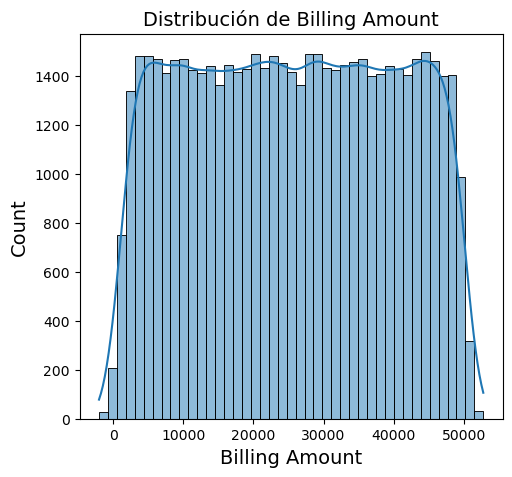

In [29]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Billing Amount'], kde=True)
plt.title('Distribución de Billing Amount')

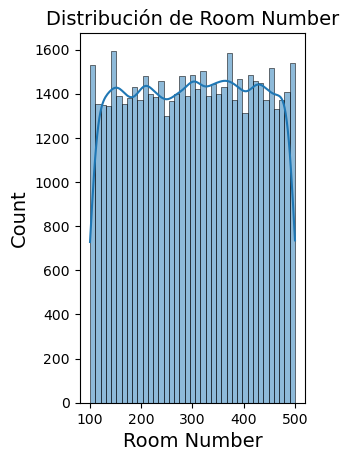

In [30]:
plt.subplot(1,2,2)
sns.histplot(df['Room Number'], kde=True)
plt.title('Distribución de Room Number')
plt.show()

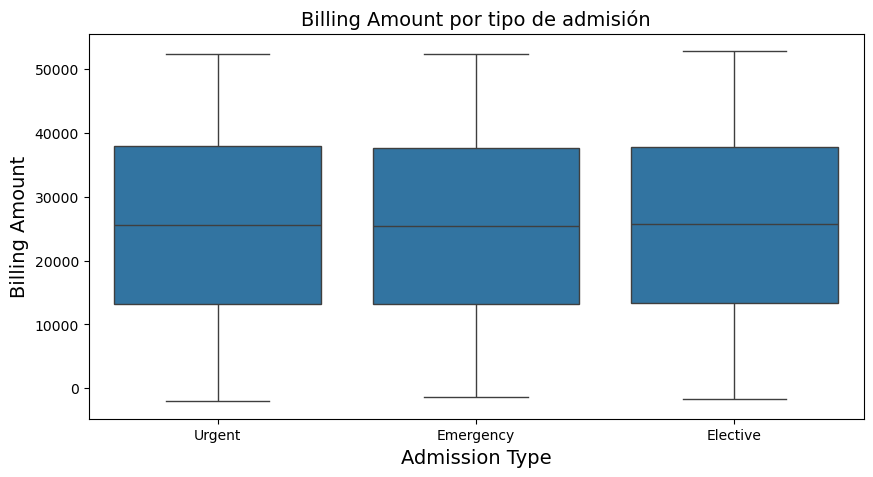

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Admission Type', y='Billing Amount', data=df)
plt.title('Billing Amount por tipo de admisión')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split


train_1, test_1 = train_test_split(df, test_size=0.2, random_state=42)


train_2, test_2 = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Admission Type'])


print("Distribución global:")
print(df['Admission Type'].value_counts(normalize=True))
print("\nDistribución training estratificado:")
print(train_2['Admission Type'].value_counts(normalize=True))
print("\nDistribución test estratificado:")
print(test_2['Admission Type'].value_counts(normalize=True))

Distribución global:
Admission Type
Elective     0.336126
Urgent       0.334703
Emergency    0.329171
Name: proportion, dtype: float64

Distribución training estratificado:
Admission Type
Elective     0.336126
Urgent       0.334707
Emergency    0.329167
Name: proportion, dtype: float64

Distribución test estratificado:
Admission Type
Elective     0.336126
Urgent       0.334685
Emergency    0.329189
Name: proportion, dtype: float64


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

# División del dataset
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# --- Billing Amount ---
train_billing = train_set["Billing Amount"].describe()
test_billing = test_set["Billing Amount"].describe()
comparison_billing = pd.concat([train_billing, test_billing], axis=1, keys=['Train', 'Test'])
comparison_billing

# --- Room Number ---
train_room = train_set["Room Number"].describe()
test_room = test_set["Room Number"].describe()
comparison_room = pd.concat([train_room, test_room], axis=1, keys=['Train', 'Test'])
comparison_room

# --- Admission Type ---
train_adm = train_set["Admission Type"].value_counts(normalize=True) * 100
test_adm = test_set["Admission Type"].value_counts(normalize=True) * 100
comparison_adm = pd.concat([train_adm, test_adm], axis=1, keys=['Train (%)', 'Test (%)'])
comparison_adm

,Train (%),Test (%)
Admission Type,,
Elective,33.763514,33.009009
Urgent,33.324324,34.054054
Emergency,32.912162,32.936937


In [34]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd


df_encoded = df.copy()


encoder = OrdinalEncoder()
encoded_data = encoder.fit_transform(df_encoded[['Admission Type']])

# Convertir a DataFrame
encoded_df = pd.DataFrame(
    encoded_data,
    columns=['AdmissionType_encoded']
)

df_result = pd.concat([df_encoded[['Billing Amount', 'Room Number', 'Admission Type']], encoded_df], axis=1)

df_result.head()

,Billing Amount,Room Number,Admission Type,AdmissionType_encoded
0,18856.281306,328,Urgent,2.0
1,33643.327287,265,Emergency,1.0
2,27955.096079,205,Emergency,1.0
3,37909.782410,450,Elective,0.0
4,14238.317814,458,Urgent,2.0


In [35]:
corr_df = df_result[['Billing Amount', 'Room Number', 'AdmissionType_encoded']]

# Calcular correlación
correlation = corr_df.corr()

correlation

,Billing Amount,Room Number,AdmissionType_encoded
Billing Amount,1.000000,-0.002943,-0.002448
Room Number,-0.002943,1.000000,-0.004339
AdmissionType_encoded,-0.002448,-0.004339,1.000000


### Exploración de las columnas 12, 13 y 14: Discharge Date, Medication yTest Results, respectivamente.

## SEMANA 8

### Pipelines

## Transformaciones 
El dataset consta de las siguientes columnas:  (Se debe poner que transformaciones se le va a hacer a cada columna)
- `Name`: 
- `Age`: 
- `Gender`: 
- `Blood Type`: 
- `Medical Condition`: 
- `Date of Admission`: 
- `Doctor`: 
- `Hospital`:
- `Insurance Provider`:
- `Billing Amount`: 
- `Room Number`: 
- `Admission Type`: 
- `Discharge Date`: 
- `Medication`:
- `Test Results`: 


- Dataset como viene y transformarlo el lo que nos interesa para entrenar.

In [67]:
dfDistTrain.shape

(44400, 19)

In [70]:
dfDistTrain.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,days_per_age,cost_per_day,billing_per_age
40666,PAUL SMith,61,Female,A+,Cancer,2022-02-10,Nichole Spencer,White-Young,Blue Cross,48943.044250,471,Elective,2022-02-25,Ibuprofen,Inconclusive,15,0.245902,3262.869617,802.344988
48983,STACey HarveY Md,68,Female,O+,Cancer,2023-11-19,Jeremy Rodriguez,"Williams, Anderson Chapman and",Medicare,4197.510208,126,Elective,2023-12-07,Lipitor,Inconclusive,18,0.264706,233.195012,61.728091
7899,DiAnE RodrIguez,43,Male,A+,Asthma,2022-08-28,Jennifer Oneal,Inc Lee,Medicare,24122.944829,263,Urgent,2022-09-21,Paracetamol,Abnormal,24,0.558140,1005.122701,560.998717
43934,rEBeCcA MCdOweLL,49,Male,B-,Obesity,2022-10-05,April Miller,Knapp-Lyons,Aetna,48934.106311,177,Urgent,2022-10-13,Paracetamol,Inconclusive,8,0.163265,6116.763289,998.655231
36171,SHErI TAylOr,20,Female,A+,Cancer,2022-04-23,Michael Brennan Jr.,Group Jones,UnitedHealthcare,34548.142723,194,Elective,2022-05-17,Penicillin,Abnormal,24,1.200000,1439.505947,1727.407136


In [105]:
dfDistTrain_labels

40666    15
48983    18
7899     24
43934     8
36171    24
         ..
54782     7
14238    11
35198     7
48978    19
46859    23
Name: Length of Stay, Length: 44400, dtype: int64

In [106]:
dfDistTrain_labels.shape

(44400,)

#### Pipeline de prueba

Explicación del siguiente código:
- Clase pipeline para hacer los flujos.
- ColumnTransformer para transformar la columna.
- SimpleImputer, para imputar los nulos.
- make_pipeline, es otra forma de hacer flujos. 

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
 
# Identificar atributos numéricos
num_attribs = ["Age", "Billing Amount", "Room Number"] ## Vamos hacer un pipeline para crear un flujo para transformarlos
 
# Identificar atributos categóricos
#cat_attribs = ["Name","Gender","Blood Type",
 #                             "Medical Condition","Doctor",
  #                            "Hospital","Insurance Provider",
   #                           "Admission Type","Medication","Test Results"]
cat_attribs = ["Blood Type", 
            "Medical Condition"]

# Pipeline: imputa y estandariza
## num_pipelin: Pipeline de los atributos numéricos, lo que va a hacer es imputar todos los atributos numéricos.
## Si hay nulos él va a buscar cuál es la mediana, los va a imputar, y va a poner eso en los nulos igual para  las demás columnas con nulos
## Después de imputadas se estandariza
num_pipeline = Pipeline([("impute", SimpleImputer(strategy="median")), 
                         ("standardize", StandardScaler()),
                        ])
 
# Pipeline: imputa y codfica categorías
## cat_pipeline: es para los atributos categóricos, y se encarga de hacer lo mismo que el anterior. 
## en este caso como son categorías lo que utiliza es la moda, les asigna el valor más frecuente.
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore")) ##podemos utilizar este método de codificación para categoría o el que elijamos
 
# Integra los pipelines
preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs),
                                  ])
 
# Otra forma de hacer el preprocessing
 
#from sklearn.compose import make_column_selector, make_column_transformer
 
#preprocessing = make_column_transformer((num_pipeline, make_column_selector(dtype_include=np.number)),
#                                        (cat_pipeline, make_column_selector(dtype_include=object)),
#                                       )

In [108]:
X = preprocessing.fit_transform(dfDistTrain) ## Agarra todos los datos y los estudia y hace las transformaciones.

In [109]:
X.shape ## agrega columnas, posiblemente del OneHotEncoder

(44400, 17)

In [110]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 222000 stored elements and shape (44400, 17)>
  Coords	Values
  (0, 0)	0.48391649727299885
  (0, 1)	1.6466717353041191
  (0, 2)	1.4717188333275961
  (0, 3)	1.0
  (0, 13)	1.0
  (1, 0)	0.8412277697145216
  (1, 1)	-1.5040156937656355
  (1, 2)	-1.5197848251961947
  (1, 9)	1.0
  (1, 13)	1.0
  (2, 0)	-0.4348839175766313
  (2, 1)	-0.10099709712322164
  (2, 2)	-0.33185438688384883
  (2, 3)	1.0
  (2, 12)	1.0
  (3, 0)	-0.1286171126267546
  (3, 1)	1.6460423841562148
  (3, 2)	-1.077562545240504
  (3, 8)	1.0
  (3, 16)	1.0
  (4, 0)	-1.608906669884492
  (4, 1)	0.6330770546786074
  (4, 2)	-0.930155118588607
  (4, 3)	1.0
  (4, 13)	1.0
  :	:
  (44395, 0)	-0.1286171126267546
  (44395, 1)	1.3092116278327555
  (44395, 2)	0.595945298513385
  (44395, 10)	1.0
  (44395, 16)	1.0
  (44396, 0)	-1.5068177349011997
  (44396, 1)	-0.48262623918359593
  (44396, 2)	-0.16710491003761105
  (44396, 3)	1.0
  (44396, 16)	1.0
  (44397, 0)	-0.7921951900181542
  (44

In [111]:
print(X[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 17)>
  Coords	Values
  (0, 0)	0.48391649727299885
  (0, 1)	1.6466717353041191
  (0, 2)	1.4717188333275961
  (0, 3)	1.0
  (0, 13)	1.0


In [112]:
import numpy as np
# Convertir la matriz dispersa a un array denso
X_dense = X.toarray()

dfDistTrainProc = pd.DataFrame(X_dense,
                               columns=preprocessing.get_feature_names_out(),
                               index=dfDistTrain.index)
dfDistTrainProc.head(2)

,num__Age,num__Billing Amount,num__Room Number,cat__Blood Type_A+,cat__Blood Type_A-,cat__Blood Type_AB+,cat__Blood Type_AB-,cat__Blood Type_B+,cat__Blood Type_B-,cat__Blood Type_O+,cat__Blood Type_O-,cat__Medical Condition_Arthritis,cat__Medical Condition_Asthma,cat__Medical Condition_Cancer,cat__Medical Condition_Diabetes,cat__Medical Condition_Hypertension,cat__Medical Condition_Obesity
40666,0.483916,1.646672,1.471719,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48983,0.841228,-1.504016,-1.519785,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Pipeline definitivo

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import make_column_selector

In [114]:
dfDistTrain['Date of Admission'] = pd.to_datetime(dfDistTrain['Date of Admission'])
dfDistTrain['Discharge Date'] = pd.to_datetime(dfDistTrain['Discharge Date'])

dfDistTrain['Días de Hospitalización'] = (
    dfDistTrain['Discharge Date'] - dfDistTrain['Date of Admission']
).dt.days

print("Columnas:", dfDistTrain.columns.tolist())
print(dfDistTrain[['Date of Admission', 'Discharge Date', 'Días de Hospitalización']].head())

Columnas: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Días de Hospitalización']
      Date of Admission Discharge Date  Días de Hospitalización
40666        2022-02-10     2022-02-25                       15
48983        2023-11-19     2023-12-07                       18
7899         2022-08-28     2022-09-21                       24
43934        2022-10-05     2022-10-13                        8
36171        2022-04-23     2022-05-17                       24


In [115]:
# Función para calcular las columnas nuevas (ratios)
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
 
# Función para asignar los nombres de las nuevas columnas (ratios)
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out
 
# Pipeline para imputar las columnas sobre las que se basarán los ratios, luego genera los ratios 
# y finalmente estandariza los resultados
def ratio_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"),
                         FunctionTransformer(column_ratio, feature_names_out=ratio_name),
                         StandardScaler())
 
# Pipeline para imputar, aplicar una transformación logarítmica y estandarizar los resultados 
log_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                             FunctionTransformer(np.log, feature_names_out="one-to-one"),
                             StandardScaler())
 
# Función para calcular las similitudes con los 10 clusters
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# Mínimo a cualquier campo numérico hay que imputarlo y estandarizarlo. 
# Pipeline para imputar y estandarizar
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
# Pipeline: imputa y codfica categorías
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore"))
 
# Integra los pipelines
preprocessing = ColumnTransformer([("cost_per_day", ratio_pipeline(), ["Billing Amount", "Días de Hospitalización"]),
                                   ("log", log_pipeline, ["Billing Amount", "Días de Hospitalización", "Age"]),
                                   ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
                                   ("num_rest", default_num_pipeline,["Room Number"]),
                                  ],
                                  remainder="drop")  # one column remaining: housing_median_age

In [116]:
# Aplica 
X = preprocessing.fit_transform(dfDistTrain)
print(type(X))
print(X.shape)

C:\Users\Daniela\anaconda3\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:387: RuntimeWarning: invalid value encountered in log
  return func(X, **(kw_args if kw_args else {}))


<class 'scipy.sparse._csr.csr_matrix'>
(44400, 108251)
